<a href="https://colab.research.google.com/github/johnmichaels4867-create/IS4487/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [2]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧

df = pd.read_csv('/content/listings.csv.gz', compression='gzip')

# Display information
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13225 entries, 0 to 13224
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13225 non-null  int64  
 1   listing_url                                   13225 non-null  object 
 2   scrape_id                                     13225 non-null  int64  
 3   last_scraped                                  13225 non-null  object 
 4   source                                        13225 non-null  object 
 5   name                                          13225 non-null  object 
 6   description                                   13088 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   13225 non-null  object 
 9   host_id                                       13225 non-null 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1534226092176355661,https://www.airbnb.com/rooms/1534226092176355661,20260627230126,2026-06-29,city scrape,Private Suite Oceanfront La Jolla,Private suite in Ocean front Estate in La Jolla,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,14064859,...,NaN,NaN,NaN,NaN,NaN,9,6,3,0,NaN
1,1151093362948878244,https://www.airbnb.com/rooms/1151093362948878244,20260627230126,2026-06-29,city scrape,Magical view,Luxury high rise building fully remodeled with...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,365015269,...,NaN,NaN,NaN,STR-08000L,NaN,1,1,0,0,NaN
2,46566873,https://www.airbnb.com/rooms/46566873,20260627230126,2026-06-28,city scrape,Highland on 60th Large 3BR 4 Beds/2 BA Near SDSU,Centrally located single-family home with a la...,NaN,https://a0.muscache.com/pictures/5b341abe-0010...,21897271,...,4.98,4.91,4.91,"STR-01411L, 644117",NaN,1,1,0,0,3.40
3,683340460312082362,https://www.airbnb.com/rooms/683340460312082362,20260627230126,2026-07-02,previous scrape,"Beautiful, Private Bed & Bath in Central Location",Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,21788590,...,5.00,4.95,5.00,"STR-06725L, 644561",NaN,2,1,1,0,0.45
4,50119879,https://www.airbnb.com/rooms/50119879,20260627230126,2026-06-29,city scrape,Wooden Craftsman Home w/ Private Backyard & Ga...,Make this entire space your new home away from...,NaN,https://a0.muscache.com/pictures/8b957cbc-f489...,117810403,...,4.93,4.98,4.79,"STR-06662L, 648042",NaN,1,1,0,0,0.95


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Top 20 columns with the most missing values:


,Missing Values,Percentage (%)
neighborhood_overview,13225,100.000000
host_since,13225,100.000000
host_response_time,13225,100.000000
host_thumbnail_url,13225,100.000000
host_acceptance_rate,13225,100.000000
host_response_rate,13225,100.000000
host_verifications,13225,100.000000
neighbourhood,13225,100.000000
host_total_listings_count,13225,100.000000
host_neighbourhood,13225,100.000000


/tmp/ipykernel_1767/3879549842.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


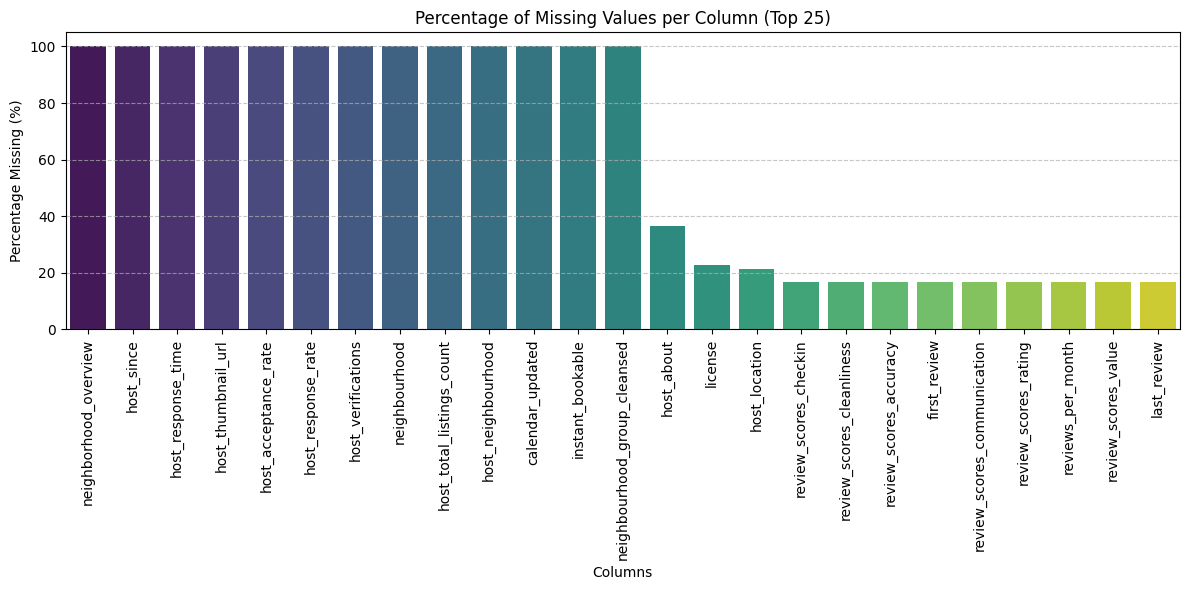

In [6]:
# Add code here 🔧

# 1. Count missing values per column
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a summary DataFrame
missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

# Display top columns with missing values
print("Top 20 columns with the most missing values:")
display(missing_df.head(20))

# 2. Visualize missing values using a bar chart for columns with missing data
plt.figure(figsize=(12, 6))
missing_cols_only = missing_df[missing_df['Missing Values'] > 0]
if not missing_cols_only.empty:
    sns.barplot(
        x=missing_cols_only.head(25).index,
        y=missing_cols_only.head(25)['Percentage (%)'],
        palette='viridis'
    )
    plt.title('Percentage of Missing Values per Column (Top 25)')
    plt.ylabel('Percentage Missing (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. neighborhood_overview, host_since, host_response_time

2. host_since, neighborhood_overview

3. host_thumbnail_url, host_picture_url


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [7]:
# Drop columns that are completely empty
cols_to_drop = ['neighborhood_overview', 'host_since', 'host_response_time']
df_cleaned = df.drop(columns=cols_to_drop)

# Confirm that the columns have been successfully removed
print(f"Original columns count: {df.shape[1]}")
print(f"New columns count after dropping: {df_cleaned.shape[1]}\n")

# Display the remaining columns information
print(df_cleaned.info())

Original columns count: 90
New columns count after dropping: 87

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13225 entries, 0 to 13224
Data columns (total 87 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13225 non-null  int64  
 1   listing_url                                   13225 non-null  object 
 2   scrape_id                                     13225 non-null  int64  
 3   last_scraped                                  13225 non-null  object 
 4   source                                        13225 non-null  object 
 5   name                                          13225 non-null  object 
 6   description                                   13088 non-null  object 
 7   picture_url                                   13225 non-null  object 
 8   host_id                                       13225 non-null  int64  
 

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. neighborhood_overview, host_since, and host_response_time

2. 100% missing values and are completely empty

3. it could cause mislieading staistics or confuse people



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [8]:
# Your code for converting column data types 🔧

# 1. Fill missing 'review_scores_rating' with the median rating to keep numeric scores valid
median_rating = df_cleaned['review_scores_rating'].median()
df_cleaned['review_scores_rating'] = df_cleaned['review_scores_rating'].fillna(median_rating)

# 2. Fill missing 'license' with a descriptive text placeholder 'No License'
df_cleaned['license'] = df_cleaned['license'].fillna('No License')

# Verify that the null values have been handled
print("Remaining missing values in 'review_scores_rating':", df_cleaned['review_scores_rating'].isnull().sum())
print("Remaining missing values in 'license':", df_cleaned['license'].isnull().sum())
print(f"Median rating used for filling: {median_rating}")

Remaining missing values in 'review_scores_rating': 0
Remaining missing values in 'license': 0
Median rating used for filling: 4.9


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. review_scores_rating and license columns

2. review_scores_rating (Median Imputation). license (Placeholder/Categorical Flag)

3. Skewing Distributions, Accuracy Risks


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

count    11856.000000
mean       483.802383
std        987.207536
min          5.500000
25%        175.457500
50%        322.920000
75%        589.000000
max      82340.820000
Name: price, dtype: float64


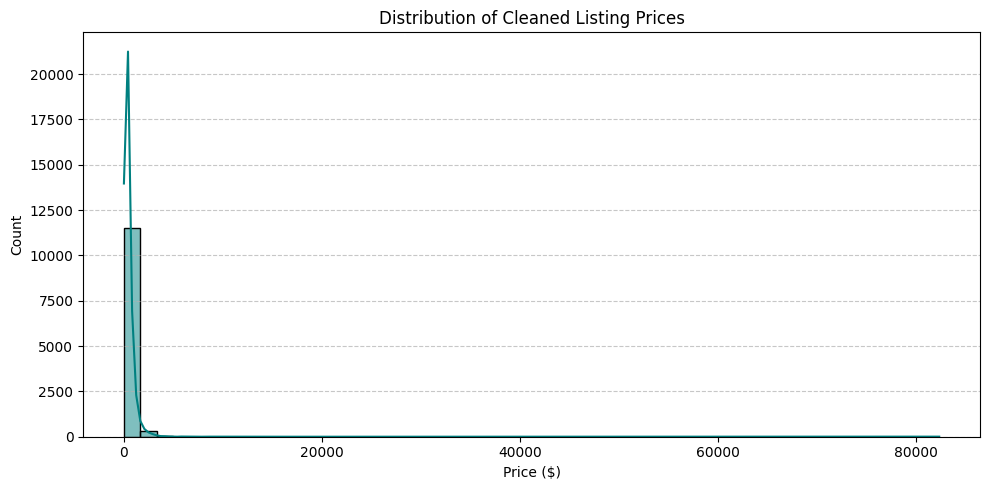

In [9]:
# Clean or adjust your dataset 🔧

# 1. Clean the 'price' column by removing '$' and ',' and converting it to float
if df_cleaned['price'].dtype == 'object':
    df_cleaned['price'] = df_cleaned['price'].astype(str).str.replace('$', '', regex=False)
    df_cleaned['price'] = df_cleaned['price'].str.replace(',', '', regex=False)
    df_cleaned['price'] = pd.to_numeric(df_cleaned['price'], errors='coerce')

# 2. Verify the conversion and display a summary
print(df_cleaned['price'].describe())

# 3. Create a quick plot of the cleaned price column
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['price'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Cleaned Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. price column.

2. all entries were treated as string objects, We stripped out the dollar sign ($), We removed comma grouping separators, converted any unparseable values to NaN instead of raising an error

3. It allows us to Calculate standard descriptive statistics.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [10]:
# Add code here 🔧

# 1. Check for exact duplicate rows
exact_duplicates = df_cleaned.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates}")

# 2. Check for duplicate listing IDs (since 'id' should be a unique primary key)
id_duplicates = df_cleaned.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {id_duplicates}")

# 3. Remove duplicates if any are found
if id_duplicates > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['id'], keep='first')
    print("Duplicate listing IDs successfully removed.")
else:
    print("No duplicate listing IDs found.")

# Display the final unique row count
print(f"Final clean dataset row count: {df_cleaned.shape[0]}")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
No duplicate listing IDs found.
Final clean dataset row count: 13225


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. no

2. If there were duplicates, we would keep the first occurance of each ID and drop the second. this would remove any duplicates.

3. Skewed Performance Metrics, User Confusion, Scheduling Conflicts

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [13]:
# export csv here 🔧

# Save the cleaned DataFrame to a CSV file for Assignment 7
df_cleaned.to_csv('cleaned_airbnb_data_6.csv', index=False)

# Verify the file is generated
import os
if os.path.exists('cleaned_airbnb_data_6.csv'):
    print("SUCCESS: 'cleaned_airbnb_data_6.csv' has been exported and saved in your directory!")
else:
    print("ERROR: File was not saved successfully.")

SUCCESS: 'cleaned_airbnb_data_6.csv' has been exported and saved in your directory!


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. __ The most challenging section was Section 5 because the price column was stored as text strings with dollar signs and commas. It required combining string cleaning functions with numeric type casting in Python, which is a common real world coding hurdle when handling raw data.
2. __ I chose to drop the neighborhood_overview, host_since, and host_response_time columns because they contained 100% missing values. It was necessary to drop them because empty columns provide zero analytical value and clutter the dataset, making future models and dashboards slower and harder to interpret.
3. __  A pricing analyst team would benefit immensely because the price column has been converted into a proper numeric format. They can now easily run mathematical calculations, find average rental prices, build automated pricing models, or spot trends without encountering string formatting errors.
4. __  If I had more time, I would explore the amenities column to parse out specific features (like Wi-Fi, pool, or parking) into individual boolean indicators, and I would clean up the remaining columns with high missing percentages, such as host_acceptance_rate or host_response_rate once they are populated.


5. __  This assignment directly supports my learning outcome of mastering data preprocessing techniques. Learning how to identify missingness, cast raw string data, and safely drop empty columns prepares me to handle complex, messy datasets in my future career as a business analyst.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"